# Modélisation Prédictive : Heart Disease Risk 

## 1. Imports et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('healthcare_synthetic_data.csv')
print(f'Dimensions initiales : {data.shape}')
data.head()


Dimensions initiales : (15000, 19)


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


## 2. Préparation des données

Les transformations ci-dessous sont identiques à celles de l'analyse exploratoire :
- `sqrt(BMI)` et `sqrt(Weight_kg)` : asymétrie positive modérée justifiant une transformation racine carrée
- `sqrt(Fasting_Blood_Sugar)` et `log(Height_cm)` : même justification
- `Stress_Level` et `Sleep_Hours` : traités comme catégoriels 


In [ ]:
# Transformations
data['SBMI']                 = np.sqrt(data['BMI'])
data['SWeight']              = np.sqrt(data['Weight_kg'])
data['S_Fasting_Blood_Sugar'] = np.sqrt(data['Fasting_Blood_Sugar'])
data['L_Height_cm']          = np.log(data['Height_cm'])

# Suppression des variables originales remplacées et de l'identifiant 
data = data.drop(columns=['Patient_ID', 'BMI', 'Weight_kg', 'Fasting_Blood_Sugar', 'Height_cm'])

# Encodage des variables catégorielles 
cat_vars = ['Gender', 'Smoking_Status', 'Family_History', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Stress_Level', 'Sleep_Hours']

for var in cat_vars:
    data[var] = data[var].astype('category')

# Renommage du genre pour lisibilité 
gender_map = {0: 'Female', 1: 'Male'}
data['Gender'] = data['Gender'].map(gender_map).astype('category')

# Heart_Disease_Risk est déjà en 0/1 dans les données 
data['Heart_Disease_Risk'] = data['Heart_Disease_Risk'].astype('category')

print('--- Types des variables ---')
print(data.dtypes)
print(f'\nValeurs manquantes : {data.isnull().sum().sum()}')


--- Types des variables ---
Age                           int64
Gender                     category
Systolic_BP                   int64
Diastolic_BP                  int64
Cholesterol_Total             int64
Cholesterol_LDL               int64
Cholesterol_HDL               int64
Smoking_Status             category
Alcohol_Consumption        category
Physical_Activity_Level    category
Family_History             category
Stress_Level               category
Sleep_Hours                category
Heart_Disease_Risk         category
SBMI                        float64
SWeight                     float64
S_Fasting_Blood_Sugar       float64
L_Height_cm                 float64
dtype: object

Valeurs manquantes : 0


### 2.1 Construction de la matrice de features

On applique `pd.get_dummies` avec `drop_first=True` sur toutes les variables catégorielles (sauf la cible) pour éviter la multicolinéarité parfaite.  
Les variables quantitatives transformées sont concaténées directement.


In [ ]:
# Encodage one-hot (drop_first=True pour éviter la colinéarité parfaite)
qual_cols = ['Gender', 'Smoking_Status', 'Family_History', 'Alcohol_Consumption',
             'Physical_Activity_Level', 'Stress_Level', 'Sleep_Hours']

df_dummies = pd.get_dummies(data[qual_cols], drop_first=True)

# Variables quantitatives (transformées + originales conservées)
quant_cols = ['SBMI', 'SWeight', 'S_Fasting_Blood_Sugar', 'L_Height_cm', 'Age', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL']

df_quant = data[quant_cols]

X = pd.concat([df_dummies, df_quant], axis=1)
y = data['Heart_Disease_Risk'].astype(int)

print(f'Nombre de features : {X.shape[1]}')
print(f'Features : {list(X.columns)}')
print()
vc = y.value_counts()
print(f'Distribution de la cible :')
print(f'  Classe 0 (faible risque) : {vc[0]} ({vc[0]/len(y)*100:.1f}%)')
print(f'  Classe 1 (risque élevé)  : {vc[1]} ({vc[1]/len(y)*100:.1f}%)')
print(f'\n→ Déséquilibre modéré (56% / 44%) : pas de rééchantillonnage nécessaire.')


Nombre de features : 33
Features : ['Gender_Male', 'Smoking_Status_1', 'Family_History_1', 'Alcohol_Consumption_1', 'Alcohol_Consumption_2', 'Physical_Activity_Level_1', 'Physical_Activity_Level_2', 'Physical_Activity_Level_3', 'Stress_Level_2', 'Stress_Level_3', 'Stress_Level_4', 'Stress_Level_5', 'Stress_Level_6', 'Stress_Level_7', 'Stress_Level_8', 'Stress_Level_9', 'Stress_Level_10', 'Sleep_Hours_5', 'Sleep_Hours_6', 'Sleep_Hours_7', 'Sleep_Hours_8', 'Sleep_Hours_9', 'Sleep_Hours_10', 'SBMI', 'SWeight', 'S_Fasting_Blood_Sugar', 'L_Height_cm', 'Age', 'Systolic_BP', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Cholesterol_HDL']

Distribution de la cible :
  Classe 0 (faible risque) : 8460 (56.4%)
  Classe 1 (risque élevé)  : 6540 (43.6%)

→ Déséquilibre modéré (56% / 44%) : pas de rééchantillonnage nécessaire.


## 3. Division train/test et normalisation

### 3.1 Pourquoi cette étape est-elle nécessaire ?

L'évaluation d'un modèle sur ses propres données d'entraînement introduit un biais d'optimisme. La création d'un jeu de test (20 %) garantit une évaluation hors échantillon rigoureuse, indispensable pour simuler de nouvelles données, valider la capacité de généralisation et écarter tout risque de sur-apprentissage. De plus, l'option stratify=y préserve la distribution initiale des classes (≈56/44) dans les deux sous-ensembles, évitant ainsi un biais de représentativité.


In [23]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

print(f'Apprentissage : {X_train.shape[0]} obs. '
      f'({y_train.mean()*100:.1f}% risque élevé)')
print(f'Test          : {X_test.shape[0]} obs. '
      f'({y_test.mean()*100:.1f}% risque élevé)')


Apprentissage : 12000 obs. (43.6% risque élevé)
Test          : 3000 obs. (43.6% risque élevé)


### 3.2 Normalisation

La normalisation des variables est requise pour garantir la convergence des modèles basés sur l'optimisation ou le calcul de distances (Régression Logistique, SVM, Réseaux de Neurones). À l'inverse, les modèles arborescents (Random Forest, Boosting) n'en nécessitent pas, de par leur invariance aux transformations monotones. D'un point de vue méthodologique, la transformation (StandardScaler) est calibrée exclusivement sur les données d'entraînement afin d'isoler totalement l'ensemble de test et de prévenir toute fuite d'information.


In [20]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  
X_test_sc  = scaler.transform(X_test)       

print('Normalisation appliquée : mean≈0, std≈1 sur chaque feature.')
print(f'Vérification : moyenne sur X_train_sc ≈ '
      f'{X_train_sc.mean():.4f} (attendu : ~0)')


Normalisation appliquée : mean≈0, std≈1 sur chaque feature.
Vérification : moyenne sur X_train_sc ≈ 0.0000 (attendu : ~0)


## 4. Modélisation

### 4.0 Fonction d'évaluation centralisée

Le calcul des performances est centralisé afin de garantir une comparaison stricte et impartiale entre les différents algorithmes. L'évaluation s'appuie sur ces trois critères principaux :

--> Accuracy : indicateur de la performance prédictive globale.

--> F1-score : métrique de robustesse, privilégiée pour limiter l'impact d'un éventuel déséquilibre entre les classes.

--> AUC-ROC : permet d'évaluer le pouvoir discriminant du modèle indépendamment du seuil de décision.


In [24]:
resultats_test = {}

def evaluer_modele(nom, modele, X_eval, y_eval, afficher=True):
    
    y_pred  = modele.predict(X_eval)
    y_proba = modele.predict_proba(X_eval)[:, 1]

    acc = accuracy_score(y_eval, y_pred)
    f1  = f1_score(y_eval, y_pred, average='macro')
    auc_val = roc_auc_score(y_eval, y_proba)

    resultats_test[nom] = {
        'Accuracy': acc,
        'F1-macro': f1,
        'AUC-ROC' : auc_val,
        'modele'  : modele,
        'X_eval'  : X_eval,
        'y_proba' : y_proba
    }

    if afficher:
        print(f'[{nom}]')
        print(f'  Accuracy = {acc:.4f}  |  F1-macro = {f1:.4f}  |  AUC-ROC = {auc_val:.4f}')
    return acc, f1, auc_val


Cette fonction centralise l'évaluation des modèles sur l'échantillon de test. Elle calcule et archive un triptyque de métriques (Accuracy, F1-macro et AUC-ROC) afin de garantir une comparaison rigoureuse et cohérente entre les différentes architectures testées.

### 4.1 Régression Logistique (avec/sans pénalisation)

La régression logistique estime la probabilité conditionnelle du risque via la fonction sigmoïde : $P(Y=1|X=x) = \sigma(\langle\beta,x\rangle)$. Afin d'optimiser le compromis biais-variance et d'atténuer l'impact de la multicolinéarité, le modèle est soumis à une recherche d'hyperparamètres par validation croisée. Cette étape évalue trois schémas de régularisation : l'absence de pénalité, la norme $L_2$ (Ridge) et la norme $L_1$ (Lasso). L'intensité de cette régularisation est pilotée par l'hyperparamètre $C$ (où $C = \frac{1}{\lambda}$).


In [ ]:
param_grid_log = {
    'penalty': ['l1', 'l2', None],
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['saga']  
}

log_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    param_grid_log, cv=5, scoring='roc_auc', n_jobs=-1
)
log_grid.fit(X_train_sc, y_train)

print(f'Meilleurs hyperparamètres : {log_grid.best_params_}')
print(f'AUC-ROC en validation croisée (cv=5) : {log_grid.best_score_:.4f}')
print()
evaluer_modele('Logistique', log_grid.best_estimator_, X_test_sc, y_test)


Meilleurs hyperparamètres : {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}
AUC-ROC en validation croisée (cv=5) : 0.8069

[Logistique]
  Accuracy = 0.7357  |  F1-macro = 0.7272  |  AUC-ROC = 0.8025


(0.7356666666666667, 0.7272499329589737, 0.8025444437214884)

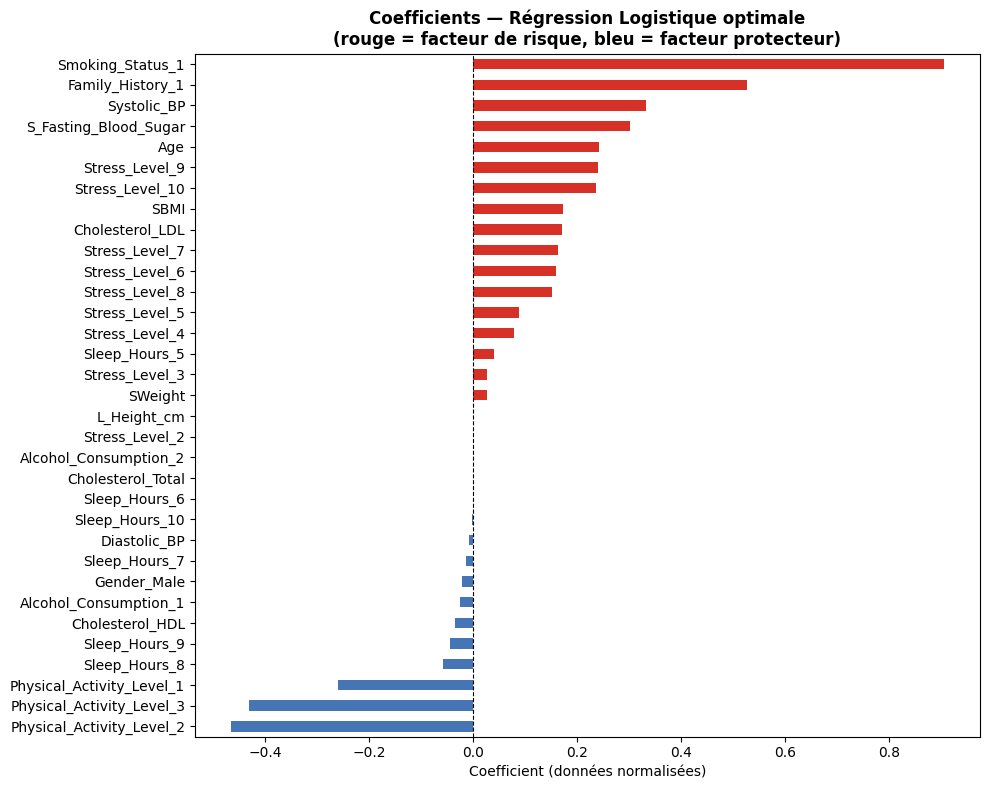

Nombre de coefficients non nuls : 28/33


In [ ]:
# Coefficients du meilleur modèle de regression logistique 
best_log = log_grid.best_estimator_
coeffs = pd.Series(best_log.coef_[0], index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d73027' if c > 0 else '#4575b4' for c in coeffs]
coeffs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_title('Coefficients : Régression Logistique optimale\n', fontweight='bold')
ax.set_xlabel('Coefficient (données normalisées)')
plt.tight_layout()
plt.show()

print(f'Nombre de coefficients non nuls : '
      f'{(np.abs(best_log.coef_[0]) > 1e-6).sum()}/{len(X.columns)}')


L'analyse des coefficients normalisés offre une lecture directe et transparente des variables influençant la prédiction. Visuellement, le modèle isole le tabagisme et l'hérédité comme les principaux vecteurs de risque cardiovasculaire, marqués par les poids positifs les plus élevés. À l'inverse, l'activité physique se distingue nettement comme le facteur protecteur majeur, ses différents niveaux affichant les coefficients négatifs les plus prononcés. Le graphique met également en lumière des effets de palier pertinents, notamment pour le stress, dont seuls les niveaux extrêmes (9 et 10) aggravent significativement l'estimation du risque.

### 4.2 Arbre de Décision Optimal (CART)

L'arbre de décision segmente récursivement l'espace des variables via des règles binaires explicites, offrant une transparence totale. Par nature, cet algorithme est invariant aux changements d'échelle et ne nécessite donc aucune normalisation. Pour contrôler sa complexité et éviter le sur-apprentissage, l'optimisation s'est concentrée sur la profondeur de l'arbre (max_depth), la taille minimale des feuilles (min_samples_leaf) et la métrique de pureté des scissions (criterion, Gini ou Entropie).

In [9]:
param_grid_tree = {
    'max_depth'        : [3, 4, 5, 6, 8, 10, None],
    'min_samples_leaf' : [5, 10, 20, 50],
    'criterion'        : ['gini', 'entropy']
}

tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree, cv=5, scoring='roc_auc', n_jobs=-1
)
# Pas de normalisation pour les arbres de décision
tree_grid.fit(X_train, y_train)

print(f'Meilleurs hyperparamètres : {tree_grid.best_params_}')
print(f'AUC-ROC en validation croisée (cv=5) : {tree_grid.best_score_:.4f}')
print(f'Profondeur de l\'arbre optimal : {tree_grid.best_estimator_.get_depth()}')
print(f'Nombre de feuilles : {tree_grid.best_estimator_.get_n_leaves()}')
print()
evaluer_modele('Arbre CART', tree_grid.best_estimator_, X_test, y_test)


Meilleurs hyperparamètres : {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 50}
AUC-ROC en validation croisée (cv=5) : 0.7626
Profondeur de l'arbre optimal : 8
Nombre de feuilles : 99

[Arbre CART]
  Accuracy = 0.7070  |  F1-macro = 0.6933  |  AUC-ROC = 0.7641


(0.707, 0.6932570644224143, 0.7640666908856935)

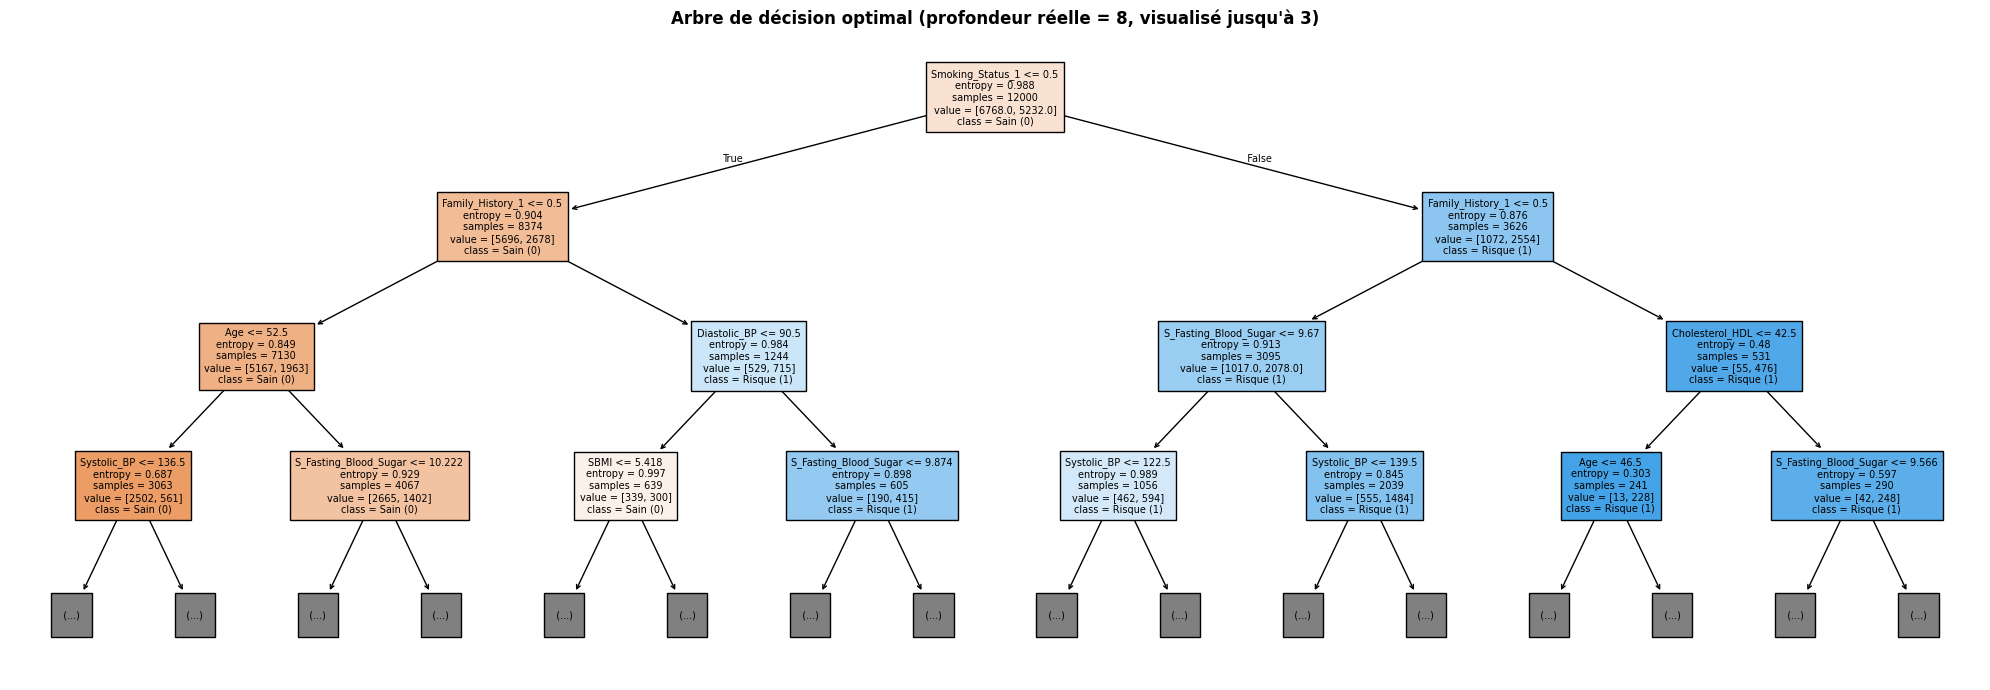

In [ ]:
# Visualisation de l'arbre (profondeur limitée à 3 pour la lisibilité)
fig, ax = plt.subplots(figsize=(20, 7))
plot_tree(
    tree_grid.best_estimator_,
    feature_names=list(X.columns),
    class_names=['Sain (0)', 'Risque (1)'],
    filled=True, max_depth=3, fontsize=7, ax=ax
)
ax.set_title(
    f'Arbre de décision optimal '
    f'(profondeur réelle = {tree_grid.best_estimator_.get_depth()}, '
    f'visualisé jusqu\'à 3)',
    fontweight='bold'
)
plt.tight_layout()
plt.show()


L'arbre de décision, ici visualisé sur ses trois premiers niveaux d'interaction, offre une cartographie explicite de la hiérarchie des risques. La scission racine s'opère logiquement sur le tabagisme (Smoking_Status_1), confirmant son statut de discriminant principal, immédiatement suivi par l'hérédité (Family_History_1) pour segmenter davantage les sous-populations. Visuellement, la topologie de l'arbre révèle une forte asymétrie : la partie droite, qui regroupe les patients cumulant ces facteurs, bascule très rapidement vers des nœuds classés à risque (teintes bleutées) et affine ses règles via des biomarqueurs comme la glycémie ou le cholestérol HDL. À l'inverse, la section gauche concentre des profils majoritairement sains (teintes orangées), où l'âge et la tension artérielle interviennent plus tardivement pour nuancer la prédiction. En explicitant ces cascades de conditions, le modèle arborescent illustre parfaitement les interactions non linéaires entre les variables cliniques et confirme la robustesse des signaux identifiés lors de la régression logistique, le tout via une matrice de décision directement lisible.

### 4.3 SVM — Support Vector Machine

L'optimisation du modèle SVM s'appuie sur la comparaison de deux géométries de séparation. Le noyau linéaire recherche un hyperplan de décision strict dans l'espace d'origine des variables, tandis que le noyau gaussien (RBF) recourt au kernel trick pour projeter les données dans un espace de Hilbert de dimension infinie, autorisant ainsi l'apprentissage de frontières non linéaires complexes. Afin d'ajuster le compromis biais-variance, la validation croisée optimise conjointement le type de noyau, la constante de régularisation C (qui contrôle la tolérance aux erreurs de classification sur la marge) et l'hyperparamètre gamma, qui définit le rayon d'influence géométrique du noyau RBF.


In [11]:
param_grid_svm = {
    'kernel': ['linear', 'rbf'],  # les deux testés (version précédente : rbf uniquement)
    'C'     : [0.1, 1, 10],
    'gamma' : ['scale', 'auto']   # ignoré si kernel='linear'
}

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm, cv=5, scoring='roc_auc', n_jobs=-1
)
svm_grid.fit(X_train_sc, y_train)

best_k = svm_grid.best_params_['kernel']
print(f'Meilleurs hyperparamètres : {svm_grid.best_params_}')
print(f'AUC-ROC en validation croisée (cv=5) : {svm_grid.best_score_:.4f}')
print()
if best_k == 'rbf':
    print('→ Noyau RBF retenu : les données ne sont pas linéairement séparables,')
    print('  le noyau gaussien permet des frontières non-linéaires via le kernel trick.')
else:
    print('→ Noyau linéaire retenu : les données sont quasi linéairement séparables,')
    print('  cohérent avec les bonnes performances de la régression logistique.')
print()
evaluer_modele('SVM', svm_grid.best_estimator_, X_test_sc, y_test)


Meilleurs hyperparamètres : {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
AUC-ROC en validation croisée (cv=5) : 0.8034

→ Noyau linéaire retenu : les données sont quasi linéairement séparables,
  cohérent avec les bonnes performances de la régression logistique.

[SVM]
  Accuracy = 0.7227  |  F1-macro = 0.7134  |  AUC-ROC = 0.7995


(0.7226666666666667, 0.7133801846493041, 0.7994660066078181)

### 4.4 Forêt Aléatoire (Random Forest)

L'algorithme des Forêts Aléatoires (Random Forest) agrège un ensemble d'arbres de décision, chacun construit sur un échantillon bootstrap indépendant. L'injection d'un double aléa, combinant ce rééchantillonnage à la sélection aléatoire d'un sous-espace de $m$ variables à chaque scission, permet de décorréler les estimateurs et de réduire drastiquement la variance globale du modèle sans en dégrader le biais. Pour maximiser cette capacité de généralisation, la validation croisée optimise simultanément la taille de la forêt (n_estimators), la profondeur structurelle (max_depth), la régularisation terminale (min_samples_leaf) ainsi que la dimension du sous-espace de recherche nodal (max_features, usuellement fixé à $\sqrt{p}$).

In [12]:
param_grid_rf = {
    'n_estimators'    : [100, 300],
    'max_depth'       : [5, 10, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features'    : ['sqrt']   
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print(f'Meilleurs hyperparamètres : {rf_grid.best_params_}')
print(f'AUC-ROC en validation croisée (cv=5) : {rf_grid.best_score_:.4f}')
print()
evaluer_modele('Random Forest', rf_grid.best_estimator_, X_test, y_test)


Meilleurs hyperparamètres : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 300}
AUC-ROC en validation croisée (cv=5) : 0.7903

[Random Forest]
  Accuracy = 0.7267  |  F1-macro = 0.7147  |  AUC-ROC = 0.7885


(0.7266666666666667, 0.7147165883258317, 0.7885236153584778)

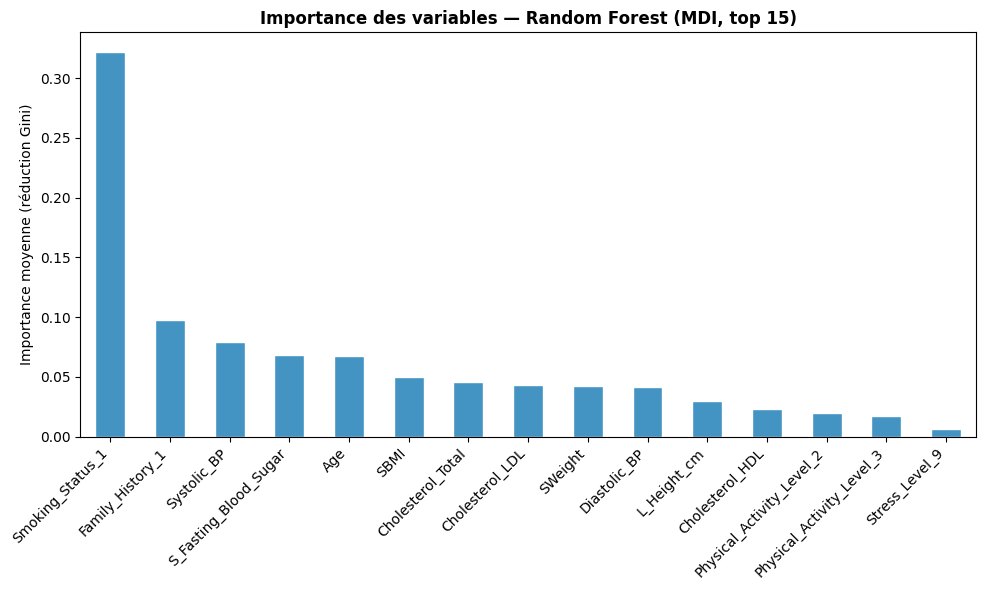

In [25]:
best_rf = rf_grid.best_estimator_
imp_rf = pd.Series(
    best_rf.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
imp_rf.plot(kind='bar', ax=ax, color='#4393c3', edgecolor='white')
ax.set_title('Importance des variables — Random Forest (MDI, top 15)', fontweight='bold')
ax.set_ylabel('Importance moyenne (réduction Gini)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


L'analyse de l'importance des variables par réduction d'impureté de Gini met en évidence la prépondérance du tabagisme dans la structuration de la forêt, avec un poids décisionnel nettement supérieur aux autres prédicteurs. Un second socle d'information se dessine ensuite autour de l'hérédité, de la pression artérielle et de la glycémie, confirmant que le modèle s'appuie sur des piliers cliniques fondamentaux. La forte similitude entre cette hiérarchie et celle établie par la régression logistique souligne la stabilité du signal extrait : les facteurs de risque identifiés restent constants malgré le changement d'architecture algorithmique, ce qui valide la robustesse de l'analyse et la fiabilité des variables sélectionnées.

### 4.5 Gradient Boosting (GradientBoostingClassifier)

Le Gradient Boosting repose sur l'agrégation séquentielle d'arbres de décision ajustés sur le gradient négatif de la fonction de perte (pseudo-résidus). Conformément aux préconisations théoriques, l'introduction d'un learning rate ($\nu$) permet de pondérer la contribution de chaque itéré pour stabiliser la convergence et limiter le risque d'overfitting. La recherche d'hyperparamètres par validation croisée optimise ainsi le nombre d'itérations ($M$), la profondeur des arbres ($J$) et le taux de sous-échantillonnage ($\eta$).



In [14]:
# Grille réduite pour limiter le temps de calcul 
# subsample < 1 implémente le Stochastic Gradient Boosting
param_grid_gb = {
    'n_estimators' : [100, 200],
    'learning_rate': [0.05, 0.1],       
    'max_depth'    : [3, 4, 5],         
    'subsample'    : [0.8, 1.0]        
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb, cv=5, scoring='roc_auc', n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print(f'Meilleurs hyperparamètres : {gb_grid.best_params_}')
print(f'AUC-ROC en validation croisée (cv=5) : {gb_grid.best_score_:.4f}')
print()
evaluer_modele('Gradient Boosting', gb_grid.best_estimator_, X_test, y_test)


Meilleurs hyperparamètres : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
AUC-ROC en validation croisée (cv=5) : 0.7992

[Gradient Boosting]
  Accuracy = 0.7250  |  F1-macro = 0.7162  |  AUC-ROC = 0.7961


(0.725, 0.7162436250834214, 0.7960938686099724)

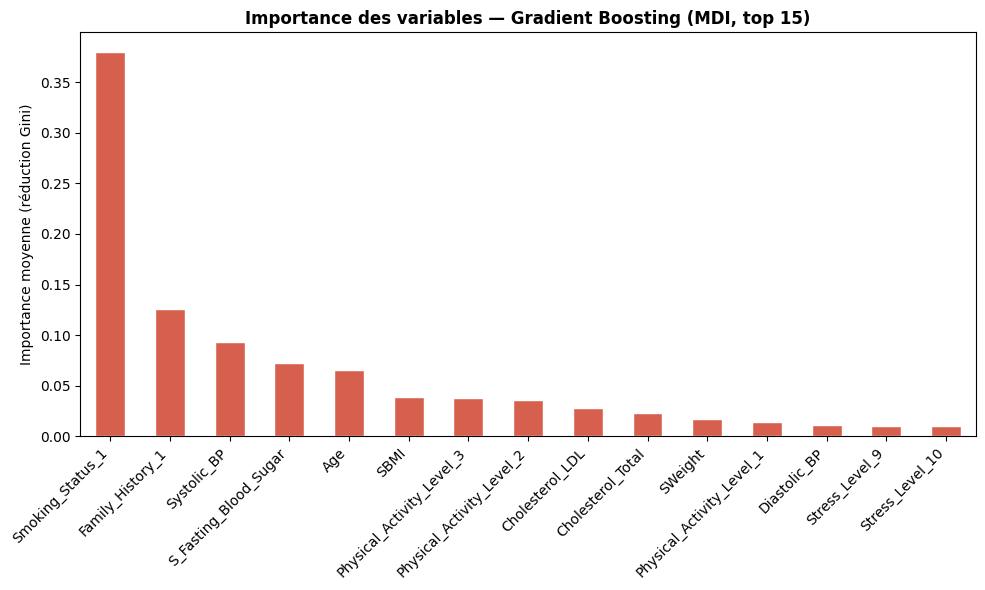

In [26]:
# moyenne des réductions d'impureté (Gini) induites par chaque variable
imp_gb = pd.Series(
    gb_grid.best_estimator_.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
imp_gb.plot(kind='bar', ax=ax, color='#d6604d', edgecolor='white')
ax.set_title('Importance des variables — Gradient Boosting (MDI, top 15)', fontweight='bold')
ax.set_ylabel('Importance moyenne (réduction Gini)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Le Gradient Boosting confirme et accentue la prépondérance du tabagisme comme levier prédictif majeur du risque cardiovasculaire. La hiérarchie des variables reste cohérente avec les modèles précédents, plaçant l'hérédité, la pression systolique et la glycémie au cœur de la décision. Cette stabilité des importances, observée à travers des paradigmes d'apprentissage différents (séquentiel pour le boosting vs parallèle pour la forêt), démontre que le signal statistique est particulièrement robuste et peu sensible au choix de l'architecture algorithmique.

### 4.6 Réseau de Neurones (MLP)

Le Perceptron Multicouche (MLP) minimise l'entropie croisée par rétropropagation pour estimer les probabilités de classe. L'optimisation porte sur l'architecture des couches cachées, la fonction d'activation et la régularisation $L_2$ (alpha).


In [ ]:
param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128, 64), (64, 32)],
    'activation'        : ['relu', 'tanh'],
    'alpha'             : [1e-4, 1e-3, 1e-2]
}

mlp_grid = GridSearchCV(
    MLPClassifier(
        max_iter=500,
        early_stopping=True,   # arrête si la loss de validation ne baisse plus
        n_iter_no_change=15,   # patience de 15 itérations sans amélioration
        random_state=42
    ),
    param_grid_mlp, cv=5, scoring='roc_auc', n_jobs=-1
)
mlp_grid.fit(X_train_sc, y_train)

print(f'Meilleurs hyperparamètres : {mlp_grid.best_params_}')
print(f'AUC-ROC en validation croisée (cv=5) : {mlp_grid.best_score_:.4f}')
print()
evaluer_modele('Réseau de Neurones', mlp_grid.best_estimator_, X_test_sc, y_test)


Meilleurs hyperparamètres : {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (64,)}
AUC-ROC en validation croisée (cv=5) : 0.8022

[Réseau de Neurones]
  Accuracy = 0.7347  |  F1-macro = 0.7254  |  AUC-ROC = 0.7987


(0.7346666666666667, 0.7253687511040452, 0.7986504218448391)

## 5. Comparaison des modèles

### 5.1 Tableau récapitulatif (métriques sur l'échantillon TEST)

L'évaluation finale repose exclusivement sur l'échantillon de test afin de garantir une estimation non biaisée de la généralisation sur des données inédites. Les procédures de validation croisée ont été strictement réservées à la phase d'optimisation des hyperparamètres et au réglage fin des modèles.


In [17]:
noms = ['Logistique', 'Arbre CART', 'SVM',
        'Random Forest', 'Gradient Boosting', 'Réseau de Neurones']

df_recap = pd.DataFrame({
    'Modèle'   : noms,
    'Accuracy' : [resultats_test[n]['Accuracy']  for n in noms],
    'F1-macro' : [resultats_test[n]['F1-macro']  for n in noms],
    'AUC-ROC'  : [resultats_test[n]['AUC-ROC']  for n in noms],
}).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)

print('=' * 58)
print('PERFORMANCES SUR L\'ÉCHANTILLON TEST (n=3 000 patients)')
print('=' * 58)
print(df_recap.to_string(index=False,
      float_format=lambda x: f'{x:.4f}' if isinstance(x, float) else x))
print()
best_name = df_recap.iloc[0]['Modèle']
best_auc  = df_recap.iloc[0]['AUC-ROC']
print(f'→ Meilleur modèle (AUC-ROC) : {best_name} ({best_auc:.4f})')

# Gain des modèles non-linéaires vs logistique
auc_log = df_recap.loc[df_recap['Modèle']=='Logistique', 'AUC-ROC'].values[0]
auc_best = df_recap.iloc[0]['AUC-ROC']
print(f'Gain AUC (meilleur vs logistique) : +{(auc_best-auc_log)*100:.2f} pts')


PERFORMANCES SUR L'ÉCHANTILLON TEST (n=3 000 patients)
            Modèle  Accuracy  F1-macro  AUC-ROC
        Logistique    0.7357    0.7272   0.8025
               SVM    0.7227    0.7134   0.7995
Réseau de Neurones    0.7347    0.7254   0.7987
 Gradient Boosting    0.7250    0.7162   0.7961
     Random Forest    0.7267    0.7147   0.7885
        Arbre CART    0.7070    0.6933   0.7641

→ Meilleur modèle (AUC-ROC) : Logistique (0.8025)
Gain AUC (meilleur vs logistique) : +0.00 pts


Les performances sur l'échantillon test confirment la robustesse de la régression logistique, qui domine l'ensemble des métriques avec un AUC-ROC de $0,8025$. Malgré leur complexité, le réseau de neurones et les modèles ensemblistes ne parviennent à générer aucun gain prédictif, affichant des scores quasi identiques ou légèrement inférieurs. Cette convergence souligne que le signal de risque est capturé de manière optimale par une frontière de décision linéaire, faisant de la logistique le choix préférentiel pour sa stabilité et sa totale transparence clinique.

### 5.2 Courbes ROC

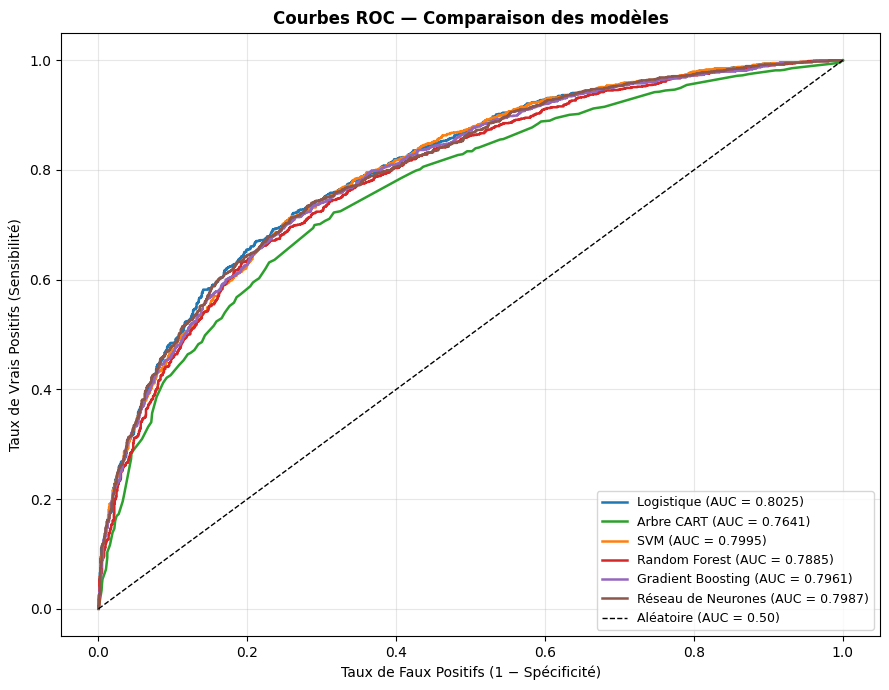

In [27]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#1f77b4','#2ca02c','#ff7f0e','#d62728','#9467bd','#8c564b']
modeles_roc = [
    ('Logistique',       log_grid.best_estimator_,  X_test_sc),
    ('Arbre CART',       tree_grid.best_estimator_, X_test),
    ('SVM',              svm_grid.best_estimator_,  X_test_sc),
    ('Random Forest',    rf_grid.best_estimator_,   X_test),
    ('Gradient Boosting',gb_grid.best_estimator_,  X_test),
    ('Réseau de Neurones',mlp_grid.best_estimator_, X_test_sc),
]

for (nom, modele, Xev), col in zip(modeles_roc, colors):
    y_p = modele.predict_proba(Xev)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_p)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=col, lw=1.8, label=f'{nom} (AUC = {roc_auc:.4f})')

ax.plot([0,1],[0,1],'k--',lw=1,label='Aléatoire (AUC = 0.50)')
ax.set_xlabel('Taux de Faux Positifs (1 − Spécificité)')
ax.set_ylabel('Taux de Vrais Positifs (Sensibilité)')
ax.set_title('Courbes ROC — Comparaison des modèles', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


La comparaison des courbes ROC met en évidence une forte convergence des performances, la majorité des modèles s'agglutinant autour d'un AUC de $0,80$. La Régression Logistique conserve une légère avance ($0,8025$), ses capacités de discrimination étant quasi identiques à celles d'architectures bien plus complexes comme le MLP ou le Gradient Boosting. Cet entrelacement des courbes suggère que la frontière de décision optimale est intrinsèquement simple, rendant les gains issus de la non-linéarité marginaux sur ce jeu de données. Seul l'arbre CART marque un décrochage net, confirmant l'insuffisance d'une segmentation binaire unique pour capturer la finesse des facteurs de risque.

### 5.3 Matrices de confusion des modèles optimaux

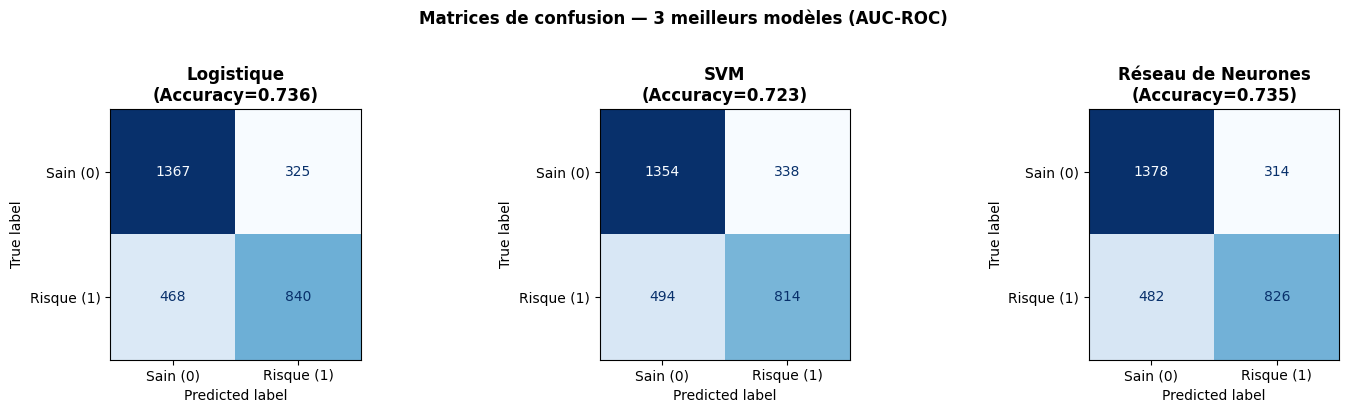

--- Classification report : Logistique ---
              precision    recall  f1-score   support

    Sain (0)       0.74      0.81      0.78      1692
  Risque (1)       0.72      0.64      0.68      1308

    accuracy                           0.74      3000
   macro avg       0.73      0.73      0.73      3000
weighted avg       0.73      0.74      0.73      3000



In [28]:
top3 = df_recap['Modèle'].head(3).tolist()
modeles_map = {
    'Logistique'       : (log_grid.best_estimator_,  X_test_sc),
    'Arbre CART'       : (tree_grid.best_estimator_, X_test),
    'SVM'              : (svm_grid.best_estimator_,  X_test_sc),
    'Random Forest'    : (rf_grid.best_estimator_,   X_test),
    'Gradient Boosting': (gb_grid.best_estimator_,  X_test),
    'Réseau de Neurones': (mlp_grid.best_estimator_, X_test_sc),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, nom in zip(axes, top3):
    modele, Xev = modeles_map[nom]
    y_pred = modele.predict(Xev)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sain (0)', 'Risque (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{nom}\n(Accuracy={acc:.3f})', fontweight='bold')
plt.suptitle('Matrices de confusion — 3 meilleurs modèles (AUC-ROC)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

best_nom  = df_recap.iloc[0]['Modèle']
best_mod, best_Xev = modeles_map[best_nom]
print(f'--- Classification report : {best_nom} ---')
print(classification_report(y_test, best_mod.predict(best_Xev),
      target_names=['Sain (0)', 'Risque (1)']))


Les matrices de confusion confirment l'homogénéité des performances : la structure des erreurs est quasi identique entre le modèle linéaire et le réseau de neurones. Le rapport de classification de la Régression Logistique révèle toutefois une asymétrie du rappel : le modèle identifie plus efficacement les sujets sains ($0,81$) que les sujets à risque ($0,64$). Ce déficit de sensibilité souligne que, malgré une précision globale satisfaisante ($74\%$), l'ajustement du seuil de décision reste un levier d'optimisation crucial pour réduire les faux négatifs dans un contexte de diagnostic médical.

## 6. Évaluation et Comparaison des Modèles

### 6.1. Synthèse des performances sur l'échantillon test

L'évaluation finale confirme la hiérarchie établie lors de la validation croisée.

| Modèle | Accuracy | F1-macro | AUC-ROC |
| :--- | :---: | :---: | :---: |
| Logistique | 0.7357 | 0.7272 | 0.8025 |
| Réseau de Neurones | 0.7347 | 0.7254 | 0.7987 |
| SVM | 0.7227 | 0.7134 | 0.7995 |
| Gradient Boosting | 0.7250 | 0.7162 | 0.7961 |
| Random Forest | 0.7267 | 0.7147 | 0.7885 |
| Arbre CART | 0.7070 | 0.6933 | 0.7641 |

Les résultats montrent que la Régression Logistique surpasse les modèles complexes. L'absence de gain significatif via les approches non-linéaires (MLP, Boosting) prouve que la structure du risque cardiaque est essentiellement linéaire dans ce jeu de données.

### 6.2. Analyse discriminante (ROC) et Matrices de confusion
L'étude des courbes ROC montre une saturation des performances autour d'un AUC de $0,80$. La superposition des courbes pour la Logistique, le SVM et le MLP souligne que le plafond de performance est atteint dès le modèle linéaire.

L'examen des matrices de confusion et du rapport de classification révèle toutefois une disparité :
* **Précision globale :** 74 %.
* **Rappel (Sains) :** 0,81.
* **Rappel (Risque) :** 0,64.

Le modèle identifie plus difficilement les patients malades. Dans un contexte clinique, un ajustement du seuil de décision (actuellement à $0,5$) serait impératif pour augmenter la sensibilité et réduire les faux négatifs.

### 6.3. Interprétabilité et Facteurs de Risque
L'avantage décisif de la Régression Logistique réside dans sa transparence totale. L'analyse des coefficients normalisés permet d'isoler les leviers biologiques du risque :

1.  **Vecteurs de risque :** Le tabagisme et l'hérédité dominent largement la prédiction, suivis par la tension systolique.
2.  **Effet protecteur :** L'activité physique se distingue comme le principal facteur de réduction du risque.
3.  **Facteurs neutres :** Le stress n'intervient de manière significative qu'à des niveaux extrêmes (9 et 10).

## 7. Conclusion
Nous retenons la Régression Logistique optimale comme modèle final. Elle offre le meilleur compromis entre puissance prédictive ($AUC = 0.80$) et robustesse. Sa capacité à fournir une explication clinique pour chaque diagnostic en fait l'outil le plus adapté à une intégration dans un protocole d'aide à la décision médicale.
